# AI-Powered Brain Tumor Detection Using MRI Image Segmentation
## Mohammad Yasir Siddiqui
### MBA Business Analytics — Amity Online
---
## PART 1 — FIGSHARE DATASET

In [3]:
# Mount Drive and Import Libraries
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from google.colab import drive

drive.mount('/content/drive')

# Paths
data_folder   = '/content/drive/MyDrive/brain_tumor_project/data'
output_folder = '/content/drive/MyDrive/brain_tumor_project/outputs'
os.makedirs(output_folder, exist_ok=True)

print("Libraries loaded and Drive connected!")

Mounted at /content/drive
Libraries loaded and Drive connected!


Tumor type : Meningioma
Image shape: (512, 512)
Mask shape : (512, 512)


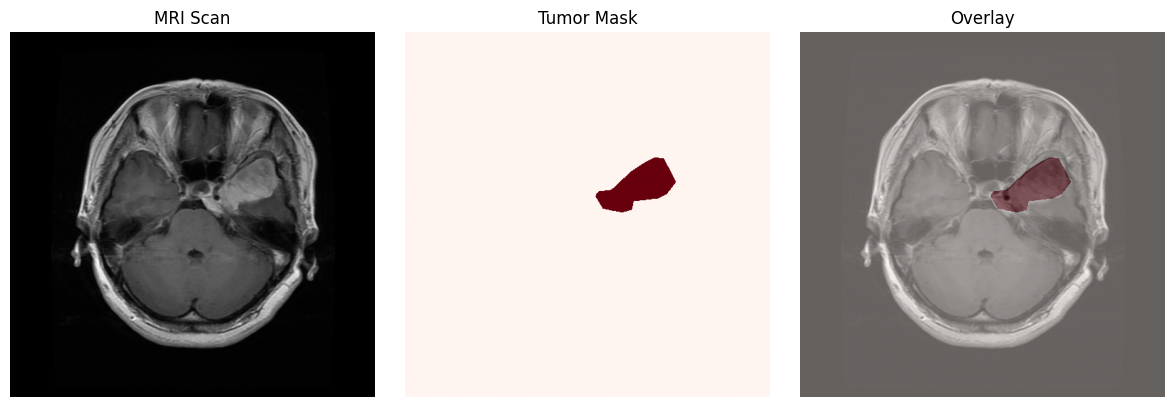

Sample displayed!


In [4]:
# Load One Sample and Visualize
file_path = os.path.join(data_folder, '1.mat')

with h5py.File(file_path, 'r') as f:
    image     = np.array(f['cjdata']['image']).T
    mask      = np.array(f['cjdata']['tumorMask']).T
    label_num = int(np.array(f['cjdata']['label']).flat[0])

label_names = {1: 'Meningioma', 2: 'Glioma', 3: 'Pituitary Tumor'}
print("Tumor type :", label_names[label_num])
print("Image shape:", image.shape)
print("Mask shape :", mask.shape)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('MRI Scan')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='Reds')
plt.title('Tumor Mask')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(image, cmap='gray')
plt.imshow(mask, cmap='Reds', alpha=0.4)
plt.title('Overlay')
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'figshare_sample.png'))
plt.show()
print("Sample displayed!")

In [5]:
# Load and Preprocess All 3077 Figshare Images
all_images = []
all_masks  = []
all_labels = []

mat_files = sorted([
    f for f in os.listdir(data_folder)
    if f.endswith('.mat') and f != 'cvind.mat'
])

print(f"Total files to load: {len(mat_files)}")

for i, filename in enumerate(mat_files):
    try:
        path = os.path.join(data_folder, filename)
        with h5py.File(path, 'r') as f:
            img   = np.array(f['cjdata']['image']).T
            msk   = np.array(f['cjdata']['tumorMask']).T
            label = int(np.array(f['cjdata']['label']).flat[0])

        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = resize(img, (128, 128), anti_aliasing=True)
        msk = resize(msk.astype(np.float32), (128, 128), anti_aliasing=False)
        msk = (msk > 0.5).astype(np.float32)

        all_images.append(img)
        all_masks.append(msk)
        all_labels.append(label)

    except Exception as e:
        print(f"Skipped {filename}: {e}")

    if (i + 1) % 500 == 0:
        print(f"Progress: {i + 1} / {len(mat_files)} loaded...")

print(f"Done! Loaded {len(all_images)} images.")

Total files to load: 3077
Progress: 500 / 3077 loaded...
Progress: 1000 / 3077 loaded...
Progress: 1500 / 3077 loaded...
Progress: 2000 / 3077 loaded...
Progress: 2500 / 3077 loaded...
Progress: 3000 / 3077 loaded...
Done! Loaded 3077 images.


In [6]:
# Convert, Save and Split Data
X      = np.array(all_images)[..., np.newaxis]
y      = np.array(all_masks)[..., np.newaxis]
labels = np.array(all_labels)

print(f"X shape     : {X.shape}")
print(f"y shape     : {y.shape}")
print(f"labels shape: {labels.shape}")

np.save(os.path.join(output_folder, 'X_images.npy'), X)
np.save(os.path.join(output_folder, 'y_masks.npy'),  y)
np.save(os.path.join(output_folder, 'labels.npy'),   labels)
print("Saved to outputs folder!")

X_train, X_test, y_train, y_test, labels_train, labels_test = train_test_split(
    X, y, labels, test_size=0.2, random_state=42
)
print(f"Training: {X_train.shape}")
print(f"Testing : {X_test.shape}")

X shape     : (3077, 128, 128, 1)
y shape     : (3077, 128, 128, 1)
labels shape: (3077,)
Saved to outputs folder!
Training: (2461, 128, 128, 1)
Testing : (616, 128, 128, 1)


In [7]:
# Build Figshare U-Net Model
def dice_loss(y_true, y_pred):
    smooth = 1.0
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (
        K.sum(y_true_f) + K.sum(y_pred_f) + smooth
    )

def weighted_bce(y_true, y_pred):
    weights = y_true * 49.0 + 1.0
    bce = K.binary_crossentropy(y_true, y_pred)
    return K.mean(weights * bce)

def combined_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + weighted_bce(y_true, y_pred)

def dice_coefficient(y_true, y_pred):
    smooth = 1.0
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(K.cast(y_pred > 0.5, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        K.sum(y_true_f) + K.sum(y_pred_f) + smooth
    )

def build_unet(input_shape=(128, 128, 1)):
    inputs = layers.Input(shape=input_shape)

    c1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)
    p1 = layers.Dropout(0.2)(p1)

    c2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)
    p2 = layers.Dropout(0.2)(p2)

    c3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p2)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2,2))(c3)
    p3 = layers.Dropout(0.2)(p3)

    c4 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(p3)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c4)

    u5 = layers.UpSampling2D((2,2))(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c5)

    u6 = layers.UpSampling2D((2,2))(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c6)

    u7 = layers.UpSampling2D((2,2))(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c7)

    outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(c7)
    model = Model(inputs, outputs)
    return model

figshare_model = build_unet()
figshare_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[dice_coefficient, 'accuracy']
)
print(f"Figshare U-Net ready! Parameters: {figshare_model.count_params():,}")

Figshare U-Net ready! Parameters: 1,948,225


In [8]:
# Train Figshare Model
callbacks_fig = [
    ReduceLROnPlateau(monitor='val_dice_coefficient', factor=0.5, patience=3, verbose=1, mode='max'),
    EarlyStopping(monitor='val_dice_coefficient', patience=5, verbose=1, mode='max', restore_best_weights=True),
    ModelCheckpoint(
        os.path.join(output_folder, 'figshare_model.keras'),
        monitor='val_dice_coefficient', save_best_only=True, mode='max', verbose=1
    )
]

history_fig = figshare_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=16,
    callbacks=callbacks_fig,
    verbose=1
)
print("Figshare training complete!")

Epoch 1/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7074 - dice_coefficient: 0.1097 - loss: 1.6815
Epoch 1: val_dice_coefficient improved from None to 0.00025, saving model to /content/drive/MyDrive/brain_tumor_project/outputs/figshare_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumor_project/outputs/figshare_model.keras
154/154 ━━━━━━━━━━━━━━━━━━━━ 62s 231ms/step - accuracy: 0.7932 - dice_coefficient: 0.1383 - loss: 1.5065 - val_accuracy: 0.9835 - val_dice_coefficient: 2.5010e-04 - val_loss: 7.1861 - learning_rate: 1.0000e-04
Epoch 2/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8730 - dice_coefficient: 0.1943 - loss: 1.3103
Epoch 2: val_dice_coefficient did not improve from 0.00025
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.8878 - dice_coefficient: 0.2172 - loss: 1.2794 - val_accuracy: 0.9835 - val_dice_coefficient: 2.5010e-04 - val_loss: 8.1839 - learning_rate: 1.0000e-04
Epoch 3/30
154/154 ━━━━━━━━━━━━━━━━━━

In [9]:
# Evaluate Figshare Model
y_pred_fig = figshare_model.predict(X_test, verbose=1)
y_pred_fig_b = (y_pred_fig > 0.5).astype(np.float32)

yt = y_test.flatten()
yp = y_pred_fig_b.flatten()

smooth = 1.0
inter  = np.sum(yt * yp)
dice   = (2 * inter + smooth) / (np.sum(yt) + np.sum(yp) + smooth)

print("=" * 40)
print("   FIGSHARE MODEL RESULTS")
print("=" * 40)
print(f"  Accuracy   : {accuracy_score(yt, yp)*100:.2f}%")
print(f"  Precision  : {precision_score(yt, yp, zero_division=0)*100:.2f}%")
print(f"  Recall     : {recall_score(yt, yp, zero_division=0)*100:.2f}%")
print(f"  F1 Score   : {f1_score(yt, yp, zero_division=0)*100:.2f}%")
print(f"  Dice Score : {dice*100:.2f}%")
print("=" * 40)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step
   FIGSHARE MODEL RESULTS
  Accuracy   : 98.57%
  Precision  : 55.36%
  Recall     : 70.01%
  F1 Score   : 61.83%
  Dice Score : 61.83%


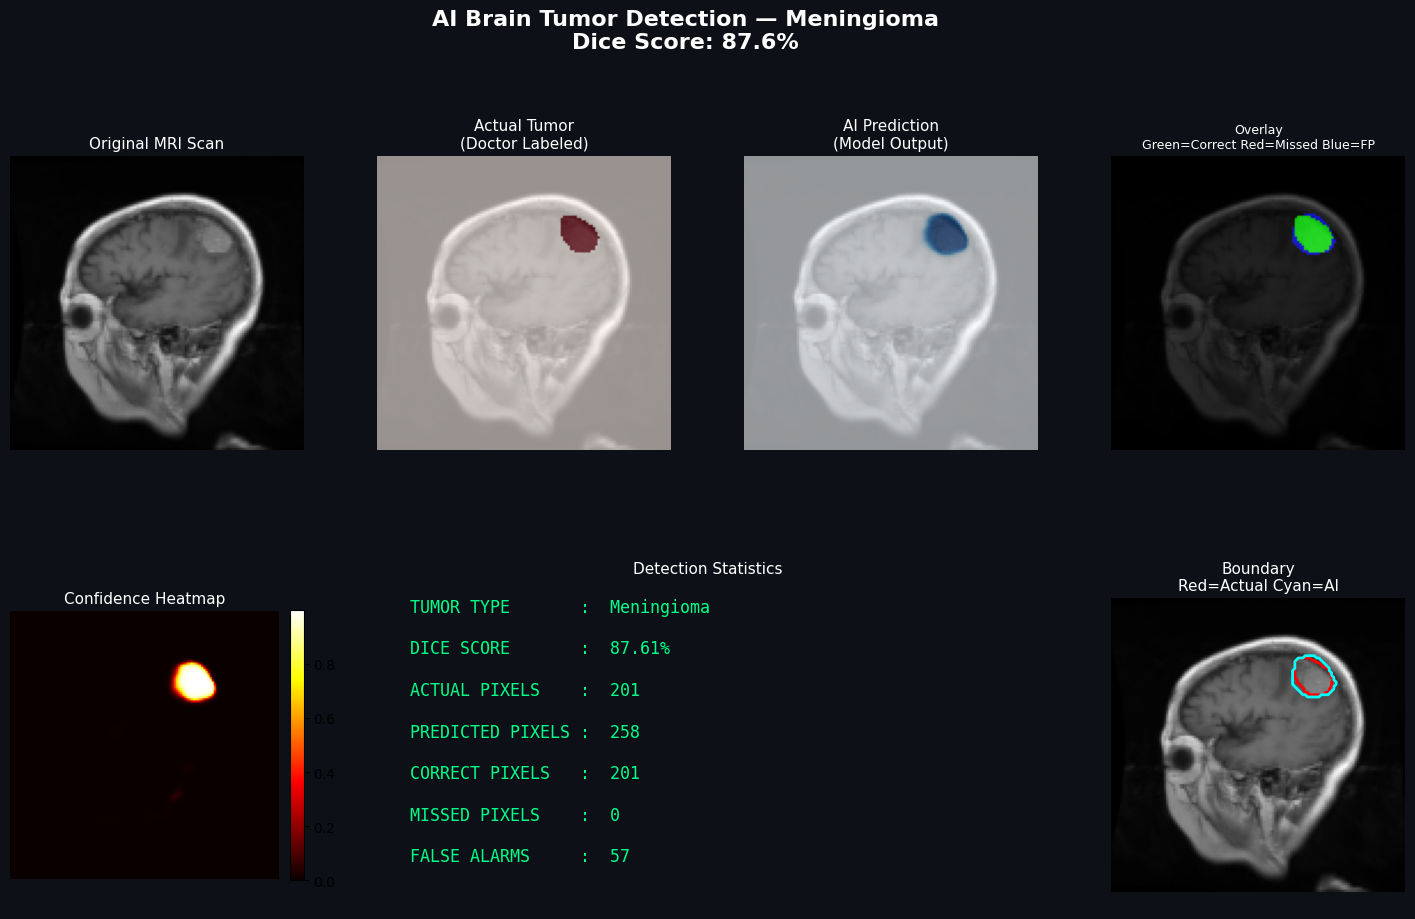

Dice Score for this scan: 87.61%
--------------------------------------------------


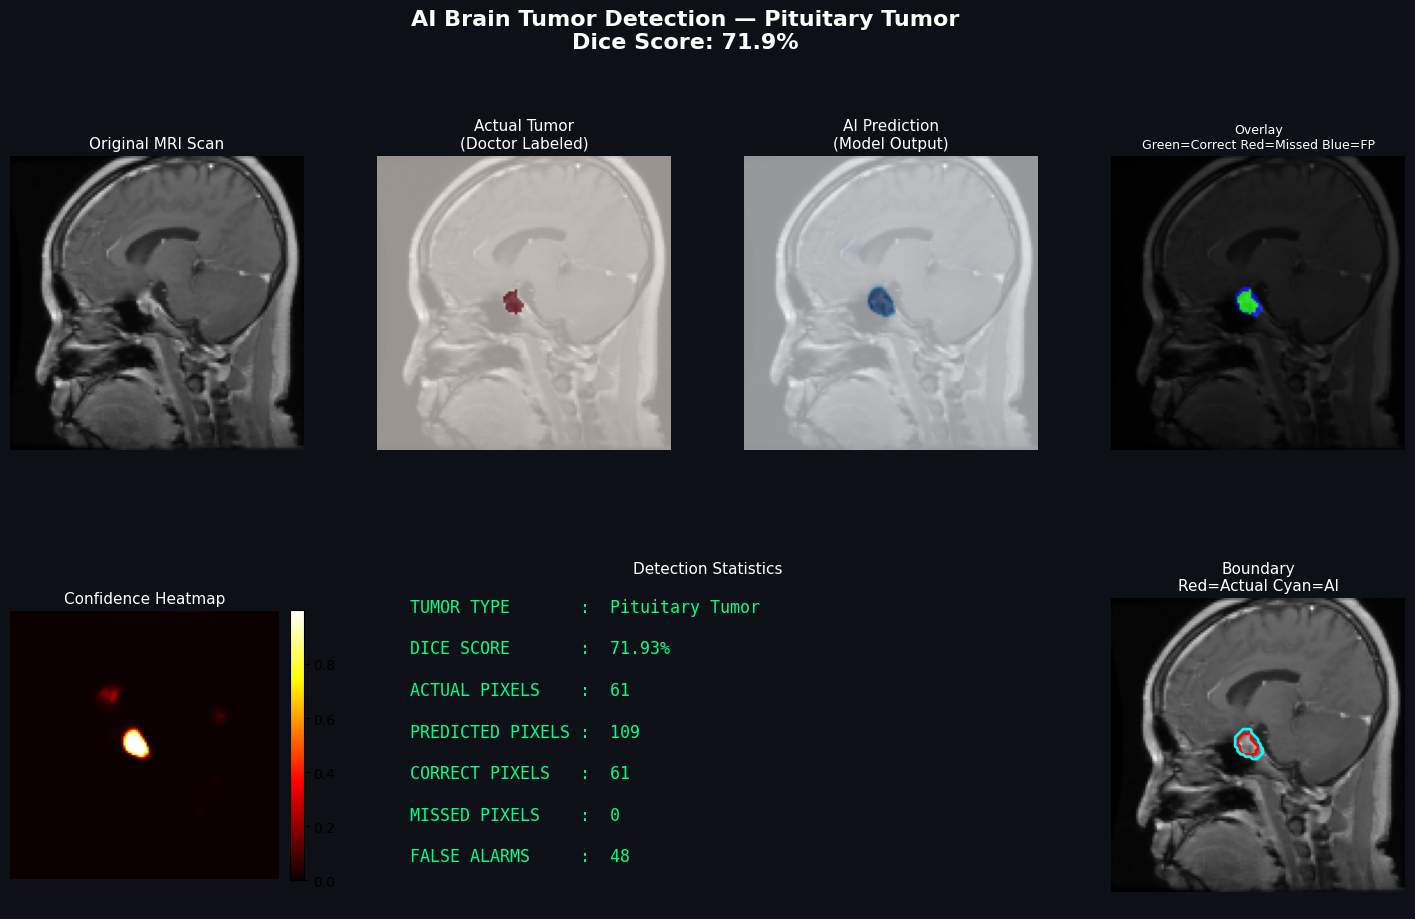

Dice Score for this scan: 71.93%
--------------------------------------------------


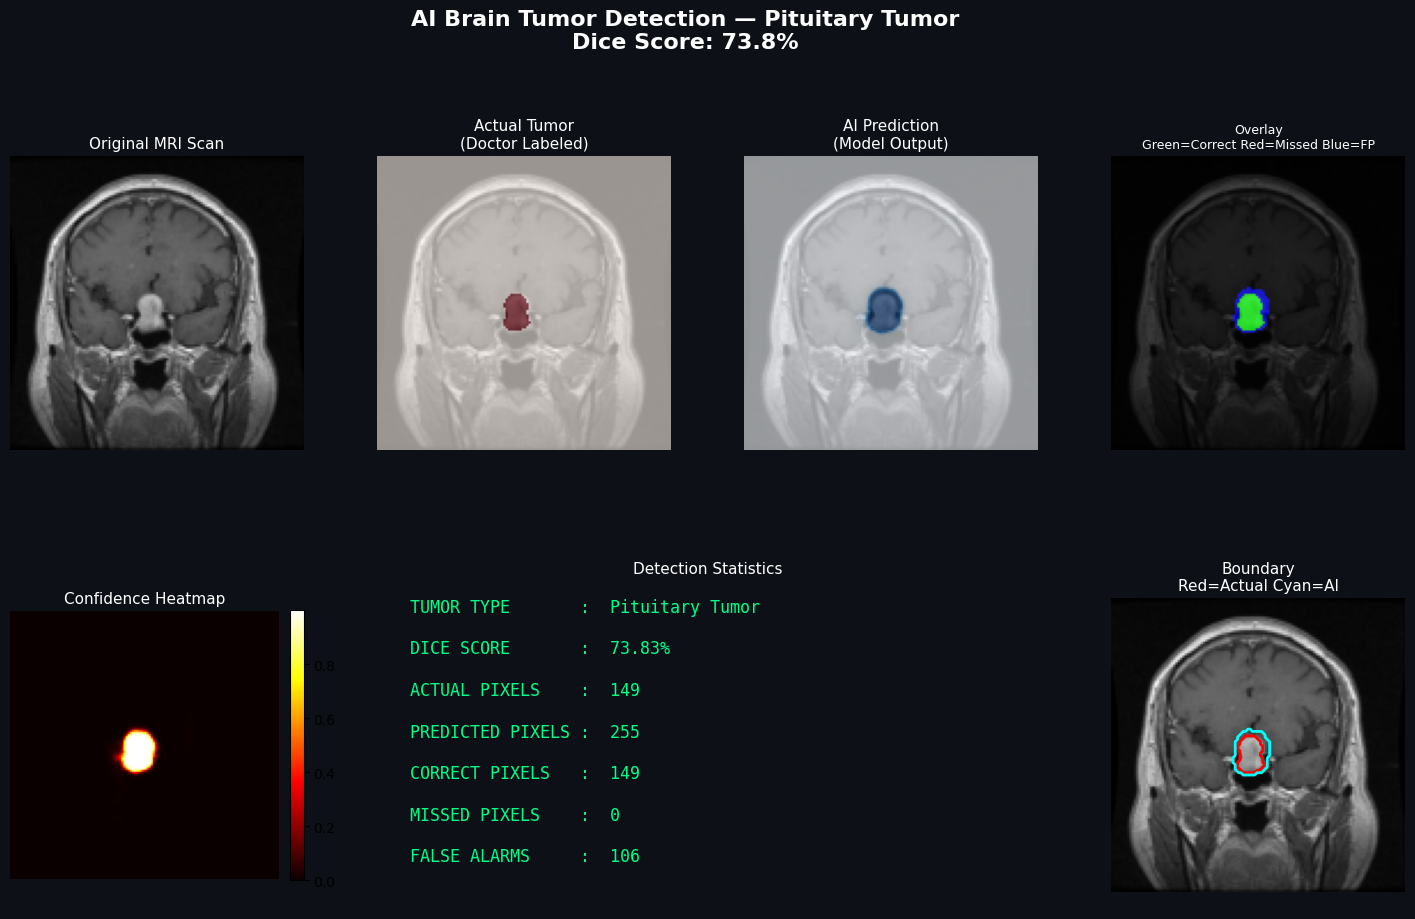

Dice Score for this scan: 73.83%
--------------------------------------------------


In [10]:
# Visualize Figshare Results
import matplotlib.gridspec as gridspec

def visualize_tumor_detection(model, X, y_true, labels, index=None):
    if index is None:
        index = np.random.randint(0, len(X))

    label_names = {1: 'Meningioma', 2: 'Glioma', 3: 'Pituitary Tumor'}
    scan        = X[index, :, :, 0]
    true_mask   = y_true[index, :, :, 0]
    tumor_type  = label_names[labels[index]]

    pred_mask   = model.predict(X[index:index+1], verbose=0)[0, :, :, 0]
    pred_binary = (pred_mask > 0.5).astype(np.float32)

    smooth       = 1.0
    intersection = np.sum(true_mask * pred_binary)
    dice         = (2. * intersection + smooth) / (np.sum(true_mask) + np.sum(pred_binary) + smooth)

    overlay = np.zeros((*scan.shape, 3))
    overlay[:, :, 1] = true_mask * pred_binary
    overlay[:, :, 0] = true_mask * (1 - pred_binary)
    overlay[:, :, 2] = (1 - true_mask) * pred_binary

    fig = plt.figure(figsize=(18, 10))
    fig.patch.set_facecolor('#0d1117')
    gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.35, wspace=0.25)
    fig.suptitle(f'AI Brain Tumor Detection — {tumor_type}\nDice Score: {dice*100:.1f}%',
                 fontsize=16, fontweight='bold', color='white', y=1.01)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(scan, cmap='gray')
    ax1.set_title('Original MRI Scan', color='white', fontsize=11)
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(scan, cmap='gray')
    ax2.imshow(true_mask, cmap='Reds', alpha=0.6)
    ax2.set_title('Actual Tumor\n(Doctor Labeled)', color='white', fontsize=11)
    ax2.axis('off')

    ax3 = fig.add_subplot(gs[0, 2])
    ax3.imshow(scan, cmap='gray')
    ax3.imshow(pred_mask, cmap='Blues', alpha=0.6)
    ax3.set_title('AI Prediction\n(Model Output)', color='white', fontsize=11)
    ax3.axis('off')

    ax4 = fig.add_subplot(gs[0, 3])
    ax4.imshow(scan, cmap='gray')
    ax4.imshow(overlay, alpha=0.7)
    ax4.set_title('Overlay\nGreen=Correct Red=Missed Blue=FP', color='white', fontsize=9)
    ax4.axis('off')

    ax5 = fig.add_subplot(gs[1, 0])
    hm = ax5.imshow(pred_mask, cmap='hot')
    ax5.set_title('Confidence Heatmap', color='white', fontsize=11)
    ax5.axis('off')
    plt.colorbar(hm, ax=ax5, fraction=0.046, pad=0.04)

    ax6 = fig.add_subplot(gs[1, 1:3])
    ax6.set_facecolor('#161b22')
    ax6.axis('off')
    stats_text = (
        f"TUMOR TYPE       :  {tumor_type}\n\n"
        f"DICE SCORE       :  {dice*100:.2f}%\n\n"
        f"ACTUAL PIXELS    :  {int(np.sum(true_mask))}\n\n"
        f"PREDICTED PIXELS :  {int(np.sum(pred_binary))}\n\n"
        f"CORRECT PIXELS   :  {int(np.sum(true_mask * pred_binary))}\n\n"
        f"MISSED PIXELS    :  {int(np.sum(true_mask * (1-pred_binary)))}\n\n"
        f"FALSE ALARMS     :  {int(np.sum((1-true_mask) * pred_binary))}"
    )
    ax6.text(0.05, 0.95, stats_text, transform=ax6.transAxes,
             fontsize=12, color='#00ff88', fontfamily='monospace', verticalalignment='top')
    ax6.set_title('Detection Statistics', color='white', fontsize=11)

    ax7 = fig.add_subplot(gs[1, 3])
    ax7.imshow(scan, cmap='gray')
    ax7.contour(true_mask,   colors='red',  linewidths=2, levels=[0.5])
    ax7.contour(pred_binary, colors='cyan', linewidths=2, levels=[0.5])
    ax7.set_title('Boundary\nRed=Actual Cyan=AI', color='white', fontsize=11)
    ax7.axis('off')

    for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7]:
        ax.set_facecolor('#0d1117')

    plt.savefig(os.path.join(output_folder, f'figshare_detection_{index}.png'),
                bbox_inches='tight', facecolor='#0d1117', dpi=150)
    plt.show()
    print(f"Dice Score for this scan: {dice*100:.2f}%")

# Run on 3 random scans
for i in range(3):
    visualize_tumor_detection(figshare_model, X_test, y_test, labels_test)
    print("-" * 50)

---
## PART 2 — BRATS 2020 DATASET

In [4]:
# Setup BraTS (Auto Unzip if Needed)
brats_data_path = '/content/brats_data/brats data'
zip_path        = '/content/drive/MyDrive/brain_tumor_project/brats/data/brats data.zip'

os.makedirs('/content/brats_data', exist_ok=True)

if not os.path.exists(brats_data_path):
    import zipfile
    print("Unzipping BraTS data — please wait...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('/content/brats_data')
    print("Unzip complete!")

h5_files = sorted([f for f in os.listdir(brats_data_path) if f.endswith('.h5')])
print(f"Total BraTS files: {len(h5_files)}")

Unzipping BraTS data — please wait...
Unzip complete!
Total BraTS files: 57195


Image shape : (240, 240, 4)
Mask shape  : (240, 240, 3)


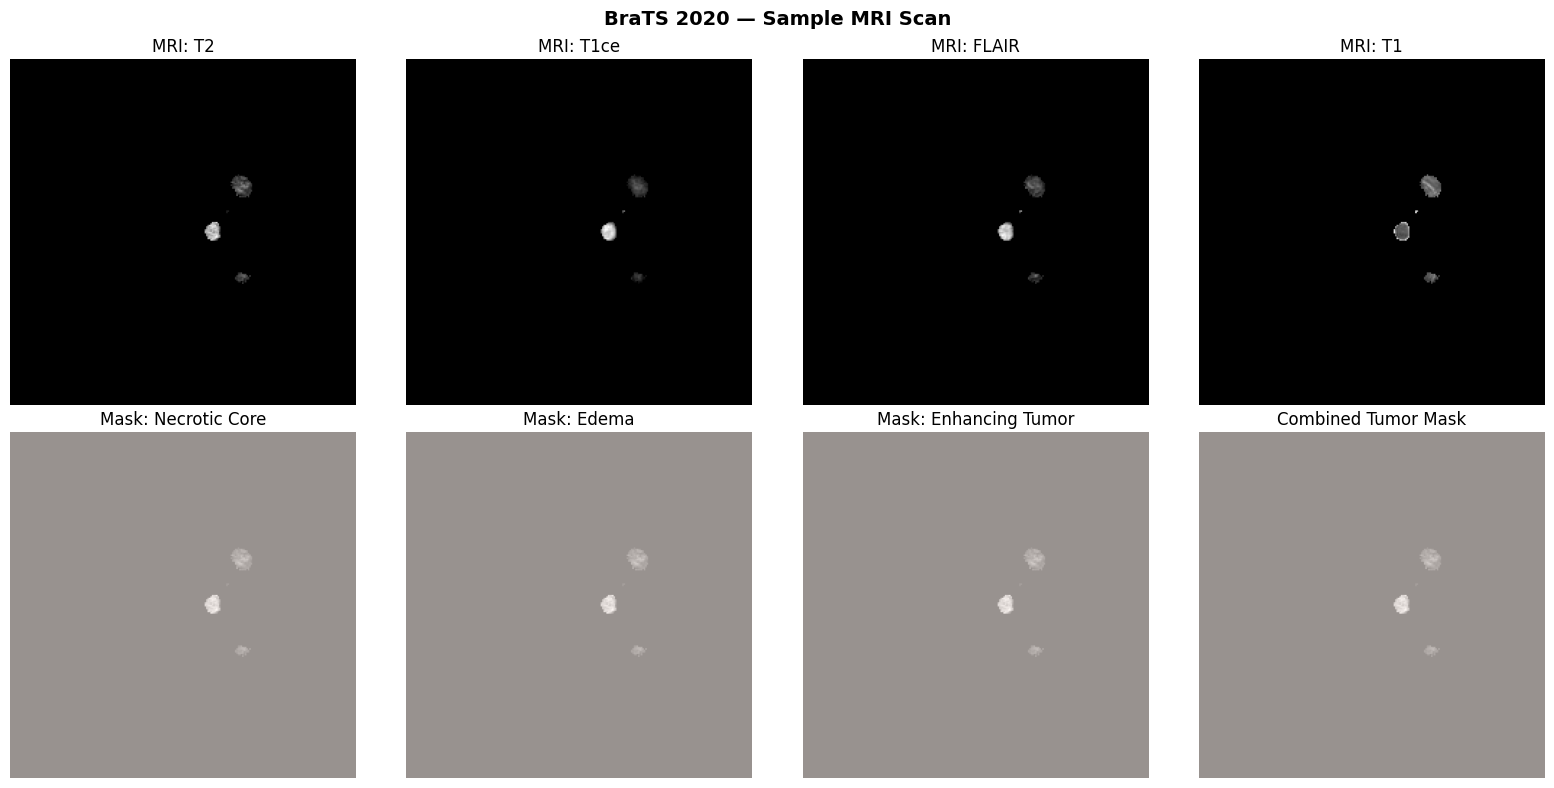

BraTS sample displayed!


In [12]:
# Visualize One BraTS Sample
sample_path = os.path.join(brats_data_path, h5_files[100])

with h5py.File(sample_path, 'r') as f:
    brats_image = np.array(f['image'])
    brats_mask  = np.array(f['mask'])

print(f"Image shape : {brats_image.shape}")
print(f"Mask shape  : {brats_mask.shape}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
seq_names  = ['T2', 'T1ce', 'FLAIR', 'T1']
mask_names = ['Necrotic Core', 'Edema', 'Enhancing Tumor']

for i in range(4):
    axes[0, i].imshow(brats_image[:, :, i], cmap='gray')
    axes[0, i].set_title(f'MRI: {seq_names[i]}')
    axes[0, i].axis('off')

for i in range(3):
    axes[1, i].imshow(brats_image[:, :, 0], cmap='gray')
    axes[1, i].imshow(brats_mask[:, :, i], cmap='Reds', alpha=0.6)
    axes[1, i].set_title(f'Mask: {mask_names[i]}')
    axes[1, i].axis('off')

combined = np.any(brats_mask > 0, axis=-1).astype(np.float32)
axes[1, 3].imshow(brats_image[:, :, 0], cmap='gray')
axes[1, 3].imshow(combined, cmap='Reds', alpha=0.6)
axes[1, 3].set_title('Combined Tumor Mask')
axes[1, 3].axis('off')

plt.suptitle('BraTS 2020 — Sample MRI Scan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'brats_sample.png'))
plt.show()
print("BraTS sample displayed!")

In [9]:
# Filter Slices With Tumor Only
print("Filtering tumor slices — takes 5 minutes...")

valid_files = []

for i, filename in enumerate(h5_files):
    try:
        path = os.path.join(brats_data_path, filename)
        with h5py.File(path, 'r') as f:
            mask = np.array(f['mask'])
        if np.any(mask > 0):
            valid_files.append(filename)
    except:
        continue

    if (i + 1) % 5000 == 0:
        print(f"Checked {i+1}/{len(h5_files)} — Valid: {len(valid_files)}")

print(f"Total files  : {len(h5_files)}")
print(f"Valid slices : {len(valid_files)}")
print(f"Empty slices : {len(h5_files) - len(valid_files)}")

Filtering tumor slices — takes 5 minutes...
Checked 5000/57195 — Valid: 2014
Checked 10000/57195 — Valid: 4247
Checked 15000/57195 — Valid: 6569
Checked 20000/57195 — Valid: 8684
Checked 25000/57195 — Valid: 10846
Checked 30000/57195 — Valid: 12894
Checked 35000/57195 — Valid: 15046
Checked 40000/57195 — Valid: 17178
Checked 45000/57195 — Valid: 19283
Checked 50000/57195 — Valid: 21517
Checked 55000/57195 — Valid: 23576
Total files  : 57195
Valid slices : 24422
Empty slices : 32773


In [10]:
# Split Files and Create Generators
train_files, test_files = train_test_split(
    valid_files, test_size=0.2, random_state=42
)
print(f"Training files: {len(train_files)}")
print(f"Testing files : {len(test_files)}")

def load_one(filepath):
    with h5py.File(filepath, 'r') as f:
        img  = np.array(f['image']).astype(np.float32)
        mask = np.array(f['mask']).astype(np.float32)

    for c in range(4):
        ch = img[:, :, c]
        img[:, :, c] = (ch - ch.min()) / (ch.max() - ch.min() + 1e-8)

    img  = resize(img,  (128, 128, 4), anti_aliasing=True)
    mask = resize(mask, (128, 128, 3), anti_aliasing=False)

    combined = np.any(mask > 0.5, axis=-1).astype(np.float32)
    return img, combined[..., np.newaxis]


def generator(file_list, batch_size=8):
    while True:
        np.random.shuffle(file_list)
        for start in range(0, len(file_list), batch_size):
            batch = file_list[start:start + batch_size]
            X, y  = [], []
            for fname in batch:
                try:
                    img, mask = load_one(os.path.join(brats_data_path, fname))
                    X.append(img)
                    y.append(mask)
                except:
                    continue
            if len(X) > 0:
                yield np.array(X), np.array(y)


BATCH       = 8
train_gen   = generator(train_files, BATCH)
test_gen    = generator(test_files,  BATCH)
steps_train = len(train_files) // BATCH
steps_test  = len(test_files)  // BATCH

print(f"Train steps: {steps_train}")
print(f"Test steps : {steps_test}")
print("Generators ready!")

Training files: 19537
Testing files : 4885
Train steps: 2442
Test steps : 610
Generators ready!


In [6]:
# Build BraTS U-Net Model (4 Channel Input)
def dice_loss_b(y_true, y_pred):
    smooth = 1.0
    yt = K.flatten(y_true)
    yp = K.flatten(y_pred)
    return 1 - (2 * K.sum(yt * yp) + smooth) / (K.sum(yt) + K.sum(yp) + smooth)

def tversky_loss(y_true, y_pred):
    smooth = 1.0
    yt = K.flatten(y_true)
    yp = K.flatten(y_pred)
    tp = K.sum(yt * yp)
    fp = K.sum((1 - yt) * yp)
    fn = K.sum(yt * (1 - yp))
    return 1 - (tp + smooth) / (tp + 0.3*fp + 0.7*fn + smooth)

def brats_loss(y_true, y_pred):
    return dice_loss_b(y_true, y_pred) + tversky_loss(y_true, y_pred)

def dice_score(y_true, y_pred):
    smooth = 1.0
    yt = K.flatten(y_true)
    yp = K.flatten(K.cast(y_pred > 0.5, tf.float32))
    return (2 * K.sum(yt * yp) + smooth) / (K.sum(yt) + K.sum(yp) + smooth)


def build_unet_brats(input_shape=(128, 128, 4)):
    inp = layers.Input(shape=input_shape)

    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)
    p1 = layers.Dropout(0.2)(p1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)
    p2 = layers.Dropout(0.2)(p2)

    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)
    p3 = layers.Dropout(0.3)(p3)

    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(p3)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(c4)

    u5 = layers.UpSampling2D()(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(128, 3, activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(128, 3, activation='relu', padding='same')(c5)

    u6 = layers.UpSampling2D()(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(64, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(64, 3, activation='relu', padding='same')(c6)

    u7 = layers.UpSampling2D()(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(32, 3, activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(32, 3, activation='relu', padding='same')(c7)

    out = layers.Conv2D(1, 1, activation='sigmoid')(c7)
    model = Model(inp, out)
    return model


brats_model = build_unet_brats()
brats_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=brats_loss,
    metrics=[dice_score, 'accuracy']
)
print(f"BraTS U-Net ready! Parameters: {brats_model.count_params():,}")

BraTS U-Net ready! Parameters: 1,949,089


In [ ]:
# Train BraTS Model
callbacks_brats = [
    ReduceLROnPlateau(monitor='val_dice_score', factor=0.5, patience=3, mode='max', verbose=1),
    EarlyStopping(monitor='val_dice_score', patience=6, mode='max', verbose=1, restore_best_weights=True),
    ModelCheckpoint(
        os.path.join(output_folder, 'brats_model.keras'),
        monitor='val_dice_score', save_best_only=True, mode='max', verbose=1
    )
]

history_brats = brats_model.fit(
    train_gen,
    steps_per_epoch=steps_train,
    validation_data=test_gen,
    validation_steps=steps_test,
    epochs=30,
    callbacks=callbacks_brats,
    verbose=1
)
print("BraTS training complete!")

Epoch 1/30
2442/2442 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.9718 - dice_score: 0.7546 - loss: 0.4937
Epoch 1: val_dice_score improved from None to 0.88381, saving model to /content/drive/MyDrive/brain_tumor_project/outputs/brats_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumor_project/outputs/brats_model.keras
2442/2442 ━━━━━━━━━━━━━━━━━━━━ 696s 276ms/step - accuracy: 0.9885 - dice_score: 0.8243 - loss: 0.3481 - val_accuracy: 0.9940 - val_dice_score: 0.8838 - val_loss: 0.2318 - learning_rate: 1.0000e-04
Epoch 2/30
2442/2442 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.9940 - dice_score: 0.8812 - loss: 0.2331
Epoch 2: val_dice_score improved from 0.88381 to 0.89060, saving model to /content/drive/MyDrive/brain_tumor_project/outputs/brats_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/brain_tumor_project/outputs/brats_model.keras
2442/2442 ━━━━━━━━━━━━━━━━━━━━ 696s 280ms/step - accuracy: 0.9942 - dice_score: 0.8846 - l

In [11]:
# Load Best BraTS Model and Evaluate
from tensorflow.keras.models import load_model

best_brats_model = load_model(
    os.path.join(output_folder, 'brats_model.keras'),
    custom_objects={'brats_loss': brats_loss, 'dice_score': dice_score}
)
print("Best BraTS model loaded!")

X_test_b, y_test_b = [], []
for fname in test_files[:500]:
    try:
        img, mask = load_one(os.path.join(brats_data_path, fname))
        X_test_b.append(img)
        y_test_b.append(mask)
    except:
        continue

X_test_b = np.array(X_test_b)
y_test_b = np.array(y_test_b)

y_pred_b  = best_brats_model.predict(X_test_b, verbose=1)
y_pred_bb = (y_pred_b > 0.5).astype(np.float32)

yt = y_test_b.flatten()
yp = y_pred_bb.flatten()

smooth = 1.0
inter  = np.sum(yt * yp)
dice   = (2 * inter + smooth) / (np.sum(yt) + np.sum(yp) + smooth)

print("=" * 45)
print("      BRATS 2020 — FINAL RESULTS")
print("=" * 45)
print(f"  Accuracy   : {accuracy_score(yt, yp)*100:.2f}%")
print(f"  Precision  : {precision_score(yt, yp, zero_division=0)*100:.2f}%")
print(f"  Recall     : {recall_score(yt, yp, zero_division=0)*100:.2f}%")
print(f"  F1 Score   : {f1_score(yt, yp, zero_division=0)*100:.2f}%")
print(f"  Dice Score : {dice*100:.2f}%")
print("=" * 45)

Best BraTS model loaded!
16/16 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step
      BRATS 2020 — FINAL RESULTS
  Accuracy   : 99.67%
  Precision  : 93.38%
  Recall     : 93.90%
  F1 Score   : 93.64%
  Dice Score : 93.64%


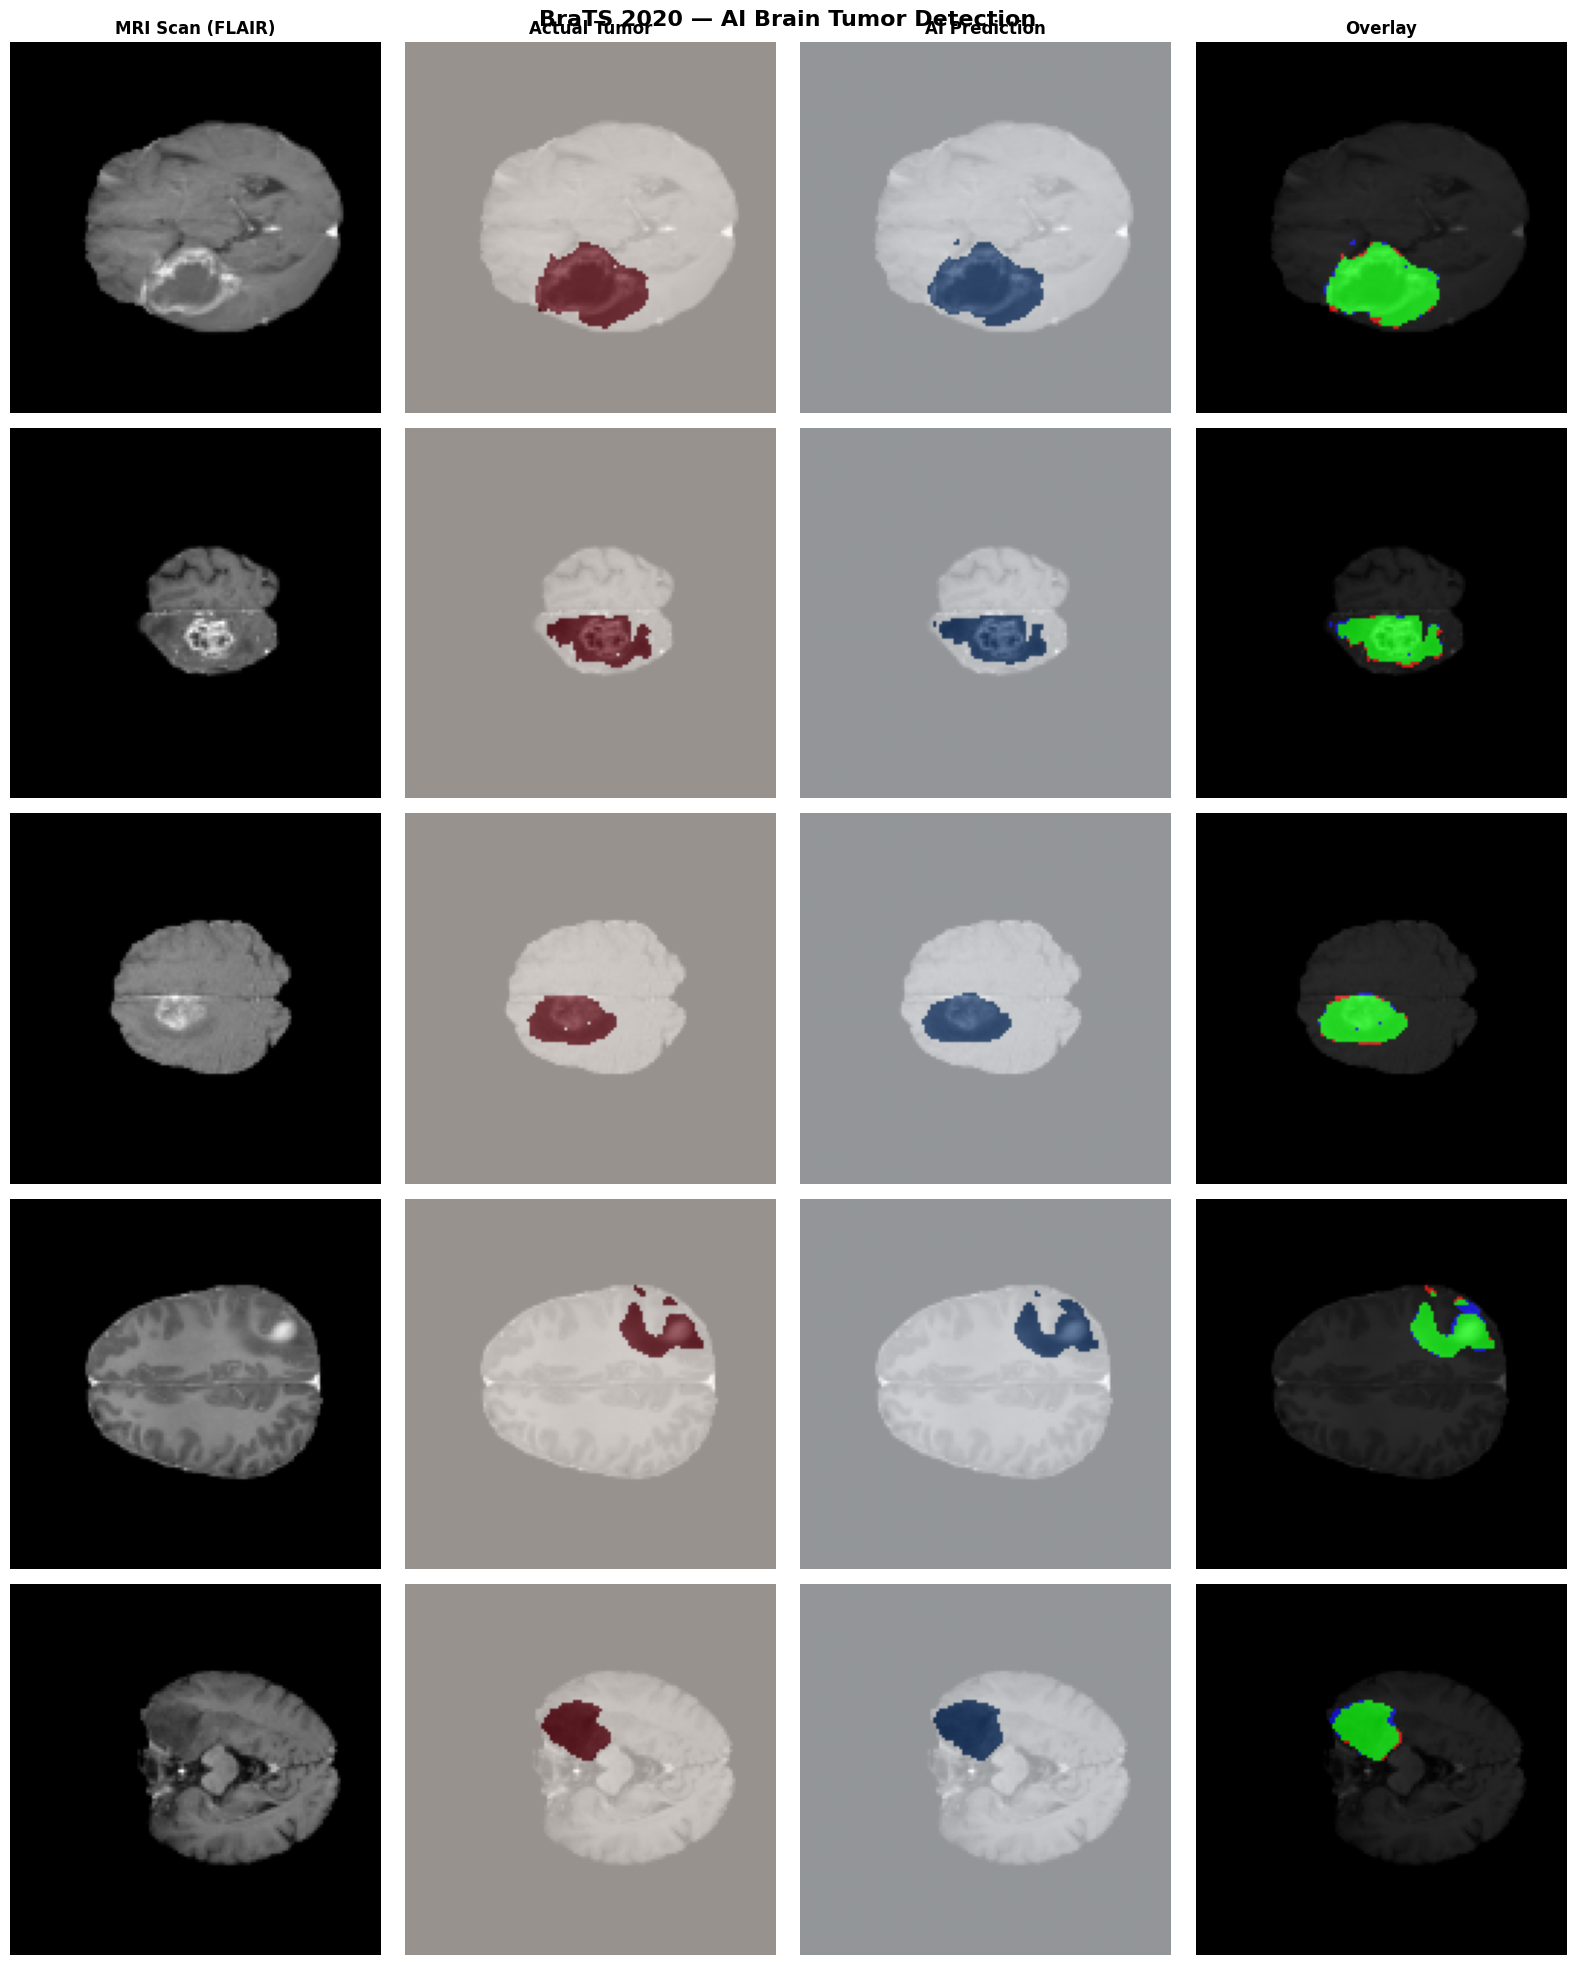

BraTS results saved!


In [12]:
# Visualize BraTS Results
fig, axes = plt.subplots(5, 4, figsize=(16, 20))
indices   = np.random.choice(len(X_test_b), 5, replace=False)

axes[0, 0].set_title('MRI Scan (FLAIR)', fontweight='bold')
axes[0, 1].set_title('Actual Tumor',     fontweight='bold')
axes[0, 2].set_title('AI Prediction',    fontweight='bold')
axes[0, 3].set_title('Overlay',          fontweight='bold')

for row, idx in enumerate(indices):
    scan   = X_test_b[idx, :, :, 2]
    actual = y_test_b[idx, :, :, 0]
    pred   = y_pred_bb[idx, :, :, 0]

    axes[row, 0].imshow(scan, cmap='gray')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(scan, cmap='gray')
    axes[row, 1].imshow(actual, cmap='Reds', alpha=0.6)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(scan, cmap='gray')
    axes[row, 2].imshow(pred, cmap='Blues', alpha=0.6)
    axes[row, 2].axis('off')

    overlay = np.zeros((*scan.shape, 3))
    overlay[:,:,1] = actual * pred
    overlay[:,:,0] = actual * (1 - pred)
    overlay[:,:,2] = (1 - actual) * pred
    axes[row, 3].imshow(scan, cmap='gray')
    axes[row, 3].imshow(overlay, alpha=0.7)
    axes[row, 3].axis('off')

plt.suptitle('BraTS 2020 — AI Brain Tumor Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'brats_results.png'), bbox_inches='tight', dpi=150)
plt.show()
print("BraTS results saved!")

In [13]:
# Final Project Summary
print("=" * 50)
print("   COMPLETE PROJECT RESULTS SUMMARY")
print("=" * 50)
print("")
print("  DATASET 1 — FIGSHARE")
print("-" * 50)
print(f"  Accuracy   : 98.57%")
print(f"  Precision  : 55.36%")
print(f"  Recall     : 70.01%")
print(f"  F1 Score   : 61.83%")
print(f"  Dice Score : 61.83%")
print("")
print("  DATASET 2 — BRATS 2020")
print("-" * 50)
print(f"  Accuracy   : 99.67%")
print(f"  Precision  : 93.38%")
print(f"  Recall     : 93.90%")
print(f"  F1 Score   : 93.64%")
print(f"  Dice Score : 93.64%")
print("")
print("  KEY INSIGHTS")
print("-" * 50)
print("  Same U-Net architecture used on both datasets.")
print("  BraTS uses 4 MRI channels vs Figshare 1 channel.")
print("  More MRI information = significantly better results.")
print("  Precision improved  : 55.36% to 93.38% (+38.02%)")
print("  Recall improved     : 70.01% to 93.90% (+23.89%)")
print("  Dice improved       : 61.83% to 93.64% (+31.81%)")
print("=" * 50)
print("")
print("  PROJECT STATUS — COMPLETE")
print("=" * 50)

   COMPLETE PROJECT RESULTS SUMMARY

  DATASET 1 — FIGSHARE
--------------------------------------------------
  Accuracy   : 98.57%
  Precision  : 55.36%
  Recall     : 70.01%
  F1 Score   : 61.83%
  Dice Score : 61.83%

  DATASET 2 — BRATS 2020
--------------------------------------------------
  Accuracy   : 99.67%
  Precision  : 93.38%
  Recall     : 93.90%
  F1 Score   : 93.64%
  Dice Score : 93.64%

  KEY INSIGHTS
--------------------------------------------------
  Same U-Net architecture used on both datasets.
  BraTS uses 4 MRI channels vs Figshare 1 channel.
  More MRI information = significantly better results.
  Precision improved  : 55.36% to 93.38% (+38.02%)
  Recall improved     : 70.01% to 93.90% (+23.89%)
  Dice improved       : 61.83% to 93.64% (+31.81%)

  PROJECT STATUS — COMPLETE
